In [1]:
import util
from models import EEGNet, EEGNet_TF

from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from tensorflow.keras import utils as np_utils
from scipy.signal import stft
from pyriemann.utils.viz import plot_confusion_matrix

['/Users/bobbeashel/Desktop/CITS4010/Project', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python38.zip', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/lib-dynload', '', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master']
1.24.3


In [2]:
timeseries = True

#training_files = ["A01T", "A02T", "A03T","A04T", "A05T", "A06T", "A07T", "A08T", "A09T"]
#test_files = ["A01E", "A02E", "A03E", "A04E", "A05E", "A06E", "A07E", "A08E", "A09E"]
training_files = ["A01T"]
test_files = ["A01E"]
tmin, tmax = 0.5, 2.5 # seconds before and after stimulus we want to record 
    # From the paper describing dataset
bandpass = [4,40]
baseline = None
amplitude_magnification = 1000 #current best = 1000

segment_len=60
sample_overlap=40
boundary=None
padding=True

# INVESTIGATE CHANGING BOUNDARY AND PADDING -> Try to get less than 17 windows -> Maybe 14
# add these as params also

In [3]:
X_train, Y_train, X_test, Y_test, chans, kernels, samples, names, sample_rate = util.get_bci_2a(
    training_files, test_files, 
    bandpass = bandpass,
    tmin = tmin, tmax = tmax,
    mode = "gdf",
    amp_mag= amplitude_magnification, 
    baseline=baseline
    )
if not timeseries:
    X_train, X_test, freq_bins_centers, time_window_centers = util.convert_to_time_frequency(X_train, X_test, sample_rate, segment_len, sample_overlap, boundary, padding)

Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['769', '770', '771', '772']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determ

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:266: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['783']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:266: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.


In [4]:
# take 50/25/25 percent of the data to train/validate/test
X_train, X_validate, Y_train, Y_validate = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train)
if timeseries:
    
    X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
    X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
    X_test       = X_test.reshape(X_test.shape[0], chans, samples, kernels)


Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)

if timeseries:
    model = EEGNet(nb_classes = 4, Chans = chans, Samples = samples, dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, dropoutType = 'Dropout')
else: #time frequency
    print(len(time_window_centers))
    model = EEGNet_TF(nb_classes = 4, Chans = chans, FreqBins=len(freq_bins_centers), TimeWindows=len(time_window_centers),dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, dropoutType = 'Dropout')

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

In [5]:
#Verbose can change
fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 0, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer])


Epoch 1: val_loss improved from inf to 1.38596, saving model to /tmp/checkpoint.h5


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss did not improve from 1.38596

Epoch 3: val_loss did not improve from 1.38596

Epoch 4: val_loss did not improve from 1.38596

Epoch 5: val_loss did not improve from 1.38596

Epoch 6: val_loss did not improve from 1.38596

Epoch 7: val_loss did not improve from 1.38596

Epoch 8: val_loss improved from 1.38596 to 1.38232, saving model to /tmp/checkpoint.h5

Epoch 9: val_loss improved from 1.38232 to 1.36981, saving model to /tmp/checkpoint.h5

Epoch 10: val_loss improved from 1.36981 to 1.34201, saving model to /tmp/checkpoint.h5

Epoch 11: val_loss improved from 1.34201 to 1.30534, saving model to /tmp/checkpoint.h5

Epoch 12: val_loss improved from 1.30534 to 1.25337, saving model to /tmp/checkpoint.h5

Epoch 13: val_loss improved from 1.25337 to 1.21360, saving model to /tmp/checkpoint.h5

Epoch 14: val_loss improved from 1.21360 to 1.14960, saving model to /tmp/checkpoint.h5

Epoch 15: val_loss improved from 1.14960 to 1.11558, saving model to /tmp/checkpoint.h5

E

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d (Conv2D)             (None, 22, 500, 8)        256       
                                                                 
 batch_normalization (Batch  (None, 22, 500, 8)        32        
 Normalization)                                                  
                                                                 
 depthwise_conv2d (Depthwis  (None, 1, 500, 16)        352       
 eConv2D)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 1, 500, 16)        64        
 chNormalization)                                                
                                                             

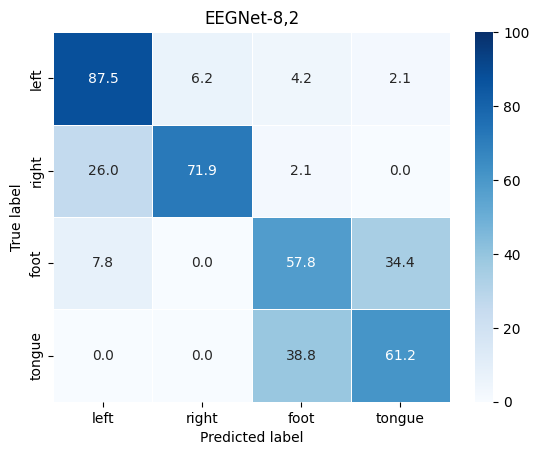

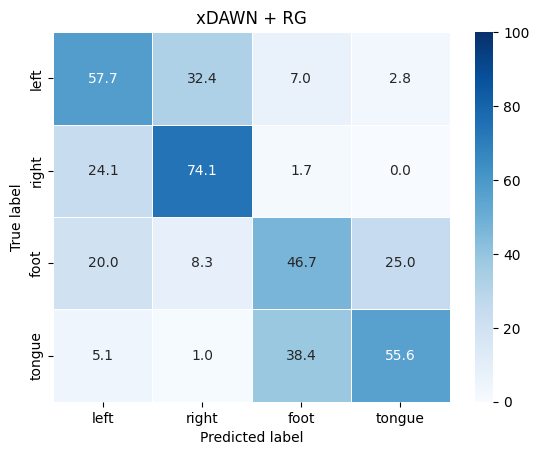

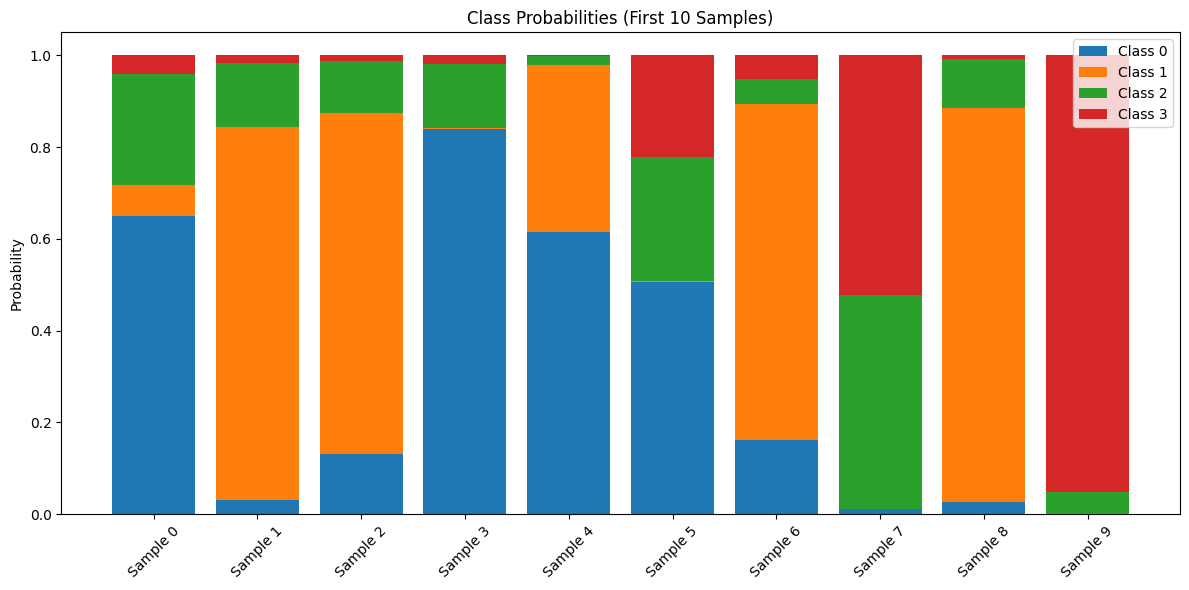

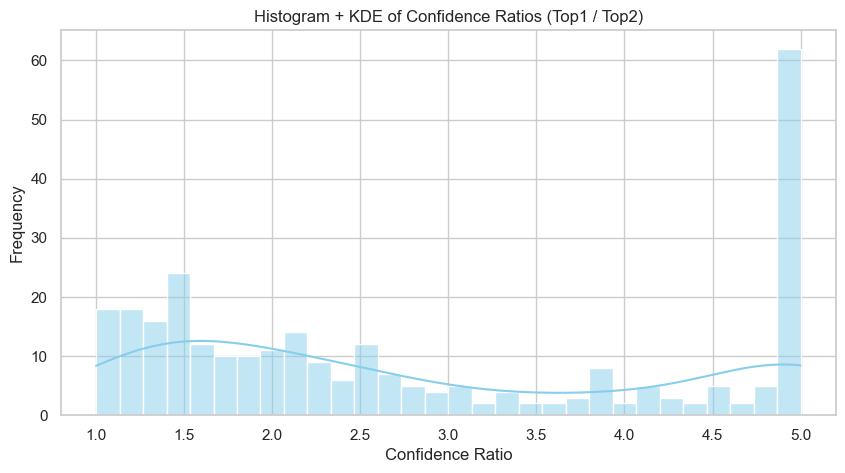

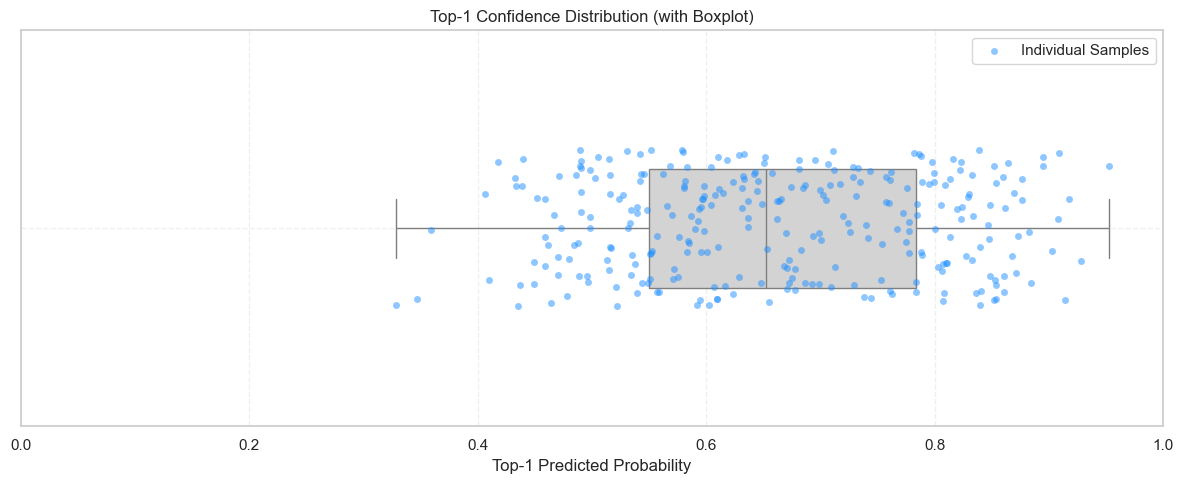

Average confidence of selected class:  0.66118157


In [6]:
#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

#k=1.2 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
# k >= 1

#preds, Y_test, mask = accept_confident_probabilities(probs, k, Y_test)
#omitted = X_test[~mask]

preds = probs.argmax(axis = -1)

acc = np.mean(preds == Y_test.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
#print(len(omitted), " samples deleted")

plt.figure(0)
plot_confusion_matrix(preds, Y_test.argmax(axis = -1), names, title = 'EEGNet-8,2')


if timeseries:
    util.xdawnrg(X_train, X_test, Y_train, Y_test, chans, samples, names)

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)
util.plot_prediction_confidence(probs)
util.plot_all_predicted_probabilities(probs)
print("Average confidence of selected class: ", np.mean(probs.max(axis=1)))
